# Notebook 06 — Pruning + DKD + FitNets Pipeline

This notebook implements a combined compression pipeline: the teacher (ResNet-110) is first pruned to remove low-magnitude weights, then used as the distillation teacher for DKD+FitNets training of the student (ResNet-20).

A pruned teacher produces softer, less overconfident output distributions than the original teacher, which improves dark knowledge transfer to the student. This pipeline combines structural compression (pruning) with knowledge transfer (DKD+FitNets).

**Previous best:** FitNets+DKD — 70.53% at 0.28M params

## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE  = '/content/drive/MyDrive/kd_project'
CKPT_DIR    = f'{DRIVE_BASE}/checkpoints'
RESULTS_DIR = f'{DRIVE_BASE}/results'

os.makedirs(CKPT_DIR,    exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

TEACHER_CKPT = f'{CKPT_DIR}/teacher_resnet110.pth'
assert os.path.exists(TEACHER_CKPT), \
    f'Teacher checkpoint not found at {TEACHER_CKPT}. Run Notebook 01 first.'

print('Drive mounted.')
print(f'Teacher checkpoint found: {TEACHER_CKPT}')

Mounted at /content/drive
Drive mounted.
Teacher checkpoint found: /content/drive/MyDrive/kd_project/checkpoints/teacher_resnet110.pth


## 2. Environment Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime > Change runtime type > GPU.')

Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition


## 3. Data Loading

In [3]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5071, 0.4867, 0.4408),
                         std=(0.2675, 0.2565, 0.2761))
])

train_dataset = torchvision.datasets.CIFAR100(root='./data', train=True,
                                               download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR100(root='./data', train=False,
                                               download=True, transform=test_transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128,
                                            shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=128,
                                            shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test samples  : {len(test_dataset):,}')

100%|██████████| 169M/169M [00:06<00:00, 26.0MB/s]


Train samples : 50,000
Test samples  : 10,000


## 4. Model Architecture with Hint Layer Support

In [4]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1    = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_channels)
        self.relu     = nn.ReLU(inplace=True)
        self.conv2    = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_channels)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    def forward(self, x):
        out  = self.relu(self.bn1(self.conv1(x)))
        out  = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

class ResNet_CIFAR(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super(ResNet_CIFAR, self).__init__()
        self.in_channels = 16
        self.conv1   = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.bn1     = nn.BatchNorm2d(16)
        self.relu    = nn.ReLU(inplace=True)
        self.layer1  = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2  = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3  = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(64 * block.expansion, num_classes)
        self._init_weights()
    def _make_layer(self, block, out_ch, num_blocks, stride):
        layers = []
        for s in [stride] + [1]*(num_blocks-1):
            layers.append(block(self.in_channels, out_ch, s))
            self.in_channels = out_ch
        return nn.Sequential(*layers)
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.constant_(m.bias, 0)
    def forward(self, x, return_hint=False):
        out    = self.relu(self.bn1(self.conv1(x)))
        out    = self.layer1(out)
        hint   = self.layer2(out)
        out    = self.layer3(hint)
        out    = self.avgpool(out)
        out    = torch.flatten(out, 1)
        logits = self.fc(out)
        if return_hint:
            return logits, hint
        return logits

def ResNet110(num_classes=100): return ResNet_CIFAR(BasicBlock, [18,18,18], num_classes)
def ResNet20(num_classes=100):  return ResNet_CIFAR(BasicBlock, [3, 3, 3],  num_classes)

print('Architecture defined.')

Architecture defined.


## 5. Pruning the Teacher

The teacher is pruned at 30% sparsity — removing the 30% of weights with the smallest magnitudes globally across all layers. The pruned teacher is then used as the distillation source. A pruned teacher produces softer output distributions, improving dark knowledge transfer.

In [5]:
def apply_global_pruning(model, sparsity):
    parameters_to_prune = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            parameters_to_prune.append((module, 'weight'))
    prune.global_unstructured(
        parameters_to_prune,
        pruning_method=prune.L1Unstructured,
        amount=sparsity
    )
    return model

def remove_pruning_masks(model):
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            try:
                prune.remove(module, 'weight')
            except:
                pass
    return model

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            correct += (model(images).argmax(dim=1) == labels).sum().item()
            total   += images.size(0)
    return 100.0 * correct / total


# Load and prune the teacher at 30% sparsity
SPARSITY = 0.30
pruned_teacher = ResNet110(num_classes=100).to(device)
pruned_teacher.load_state_dict(torch.load(TEACHER_CKPT, map_location=device))

acc_before = evaluate(pruned_teacher, test_loader, device)
print(f'Teacher before pruning : {acc_before:.2f}%')

pruned_teacher = apply_global_pruning(pruned_teacher, SPARSITY)
acc_after = evaluate(pruned_teacher, test_loader, device)
print(f'Teacher after pruning  : {acc_after:.2f}%  ({SPARSITY*100:.0f}% sparsity)')

# Freeze pruned teacher — used only for distillation
pruned_teacher.eval()
for param in pruned_teacher.parameters():
    param.requires_grad = False

print(f'Pruned teacher frozen and ready for distillation.')

Teacher before pruning : 72.96%
Teacher after pruning  : 72.57%  (30% sparsity)
Pruned teacher frozen and ready for distillation.


## 6. Loss Functions — DKD + Hint

In [6]:
def dkd_loss(student_logits, teacher_logits, labels, T, alpha, beta):
    student_softmax = F.softmax(student_logits / T, dim=1)
    teacher_softmax = F.softmax(teacher_logits / T, dim=1)
    batch_size      = labels.shape[0]
    num_classes     = student_logits.shape[1]
    target_mask     = torch.zeros(batch_size, num_classes, device=labels.device)
    target_mask.scatter_(1, labels.unsqueeze(1), 1.0)

    student_target = (student_softmax * target_mask).sum(dim=1, keepdim=True)
    teacher_target = (teacher_softmax * target_mask).sum(dim=1, keepdim=True)
    student_tckd   = torch.cat([student_target, 1 - student_target], dim=1)
    teacher_tckd   = torch.cat([teacher_target, 1 - teacher_target], dim=1)
    tckd           = F.kl_div(torch.log(student_tckd + 1e-8),
                               teacher_tckd, reduction='batchmean') * (T ** 2)

    non_target_mask    = 1.0 - target_mask
    student_non_target = student_softmax * non_target_mask
    teacher_non_target = teacher_softmax * non_target_mask
    student_non_target = student_non_target / (student_non_target.sum(dim=1, keepdim=True) + 1e-8)
    teacher_non_target = teacher_non_target / (teacher_non_target.sum(dim=1, keepdim=True) + 1e-8)
    nckd               = F.kl_div(torch.log(student_non_target + 1e-8),
                                   teacher_non_target, reduction='batchmean') * (T ** 2)

    hard_loss = F.cross_entropy(student_logits, labels)
    return hard_loss + alpha * tckd + beta * nckd


def fitnet_dkd_loss(student_logits, teacher_logits, student_hint, teacher_hint,
                    labels, T, alpha, beta, hint_weight):
    output_loss = dkd_loss(student_logits, teacher_logits, labels, T, alpha, beta)
    hint_loss   = F.mse_loss(student_hint, teacher_hint)
    return output_loss + hint_weight * hint_loss


print('Loss functions defined.')

Loss functions defined.


## 7. Training Functions

In [7]:
def train_hint_epoch(student, teacher, loader, optimizer, device):
    student.train(); teacher.eval()
    total_loss, total = 0, 0
    for images, _ in loader:
        images = images.to(device)
        with torch.no_grad():
            _, teacher_hint = teacher(images, return_hint=True)
        _, student_hint = student(images, return_hint=True)
        loss = F.mse_loss(student_hint, teacher_hint)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * images.size(0)
        total      += images.size(0)
    return total_loss / total


def train_epoch(student, teacher, loader, optimizer, T, alpha, beta, hint_weight, device):
    student.train(); teacher.eval()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            teacher_logits, teacher_hint = teacher(images, return_hint=True)
        student_logits, student_hint = student(images, return_hint=True)
        loss = fitnet_dkd_loss(student_logits, teacher_logits,
                               student_hint, teacher_hint,
                               labels, T, alpha, beta, hint_weight)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (student_logits.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, 100.0 * correct / total


print('Functions defined.')

Functions defined.


## 8. Training Configuration

In [8]:
HINT_EPOCHS   = 20
FULL_EPOCHS   = 100
LEARNING_RATE = 0.1
MOMENTUM      = 0.9
WEIGHT_DECAY  = 5e-4
T             = 4
ALPHA         = 1.0
BETA          = 1.0
HINT_WEIGHT   = 0.5

print(f'Stage 1 (hint alignment) : {HINT_EPOCHS} epochs')
print(f'Stage 2 (full training)  : {FULL_EPOCHS} epochs')
print(f'T={T}, alpha={ALPHA}, beta={BETA}, hint_weight={HINT_WEIGHT}')

Stage 1 (hint alignment) : 20 epochs
Stage 2 (full training)  : 100 epochs
T=4, alpha=1.0, beta=1.0, hint_weight=0.5


## 9. Stage 1 — Hint Alignment with Pruned Teacher

In [9]:
student   = ResNet20(num_classes=100).to(device)
optimizer = optim.SGD(student.parameters(), lr=0.01,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)

print(f'Stage 1: Hint alignment for {HINT_EPOCHS} epochs...')
print('=' * 60)
start_time = time.time()

for epoch in range(1, HINT_EPOCHS + 1):
    hint_l  = train_hint_epoch(student, pruned_teacher, train_loader, optimizer, device)
    elapsed = (time.time() - start_time) / 60
    print(f'Hint Epoch [{epoch:2d}/{HINT_EPOCHS}]  Hint Loss: {hint_l:.4f}  Elapsed: {elapsed:.1f}m')

print('=' * 60)
print('Stage 1 done.')

Stage 1: Hint alignment for 20 epochs...
Hint Epoch [ 1/20]  Hint Loss: 0.8854  Elapsed: 0.1m
Hint Epoch [ 2/20]  Hint Loss: 0.6845  Elapsed: 0.1m
Hint Epoch [ 3/20]  Hint Loss: 0.6291  Elapsed: 0.2m
Hint Epoch [ 4/20]  Hint Loss: 0.5879  Elapsed: 0.3m
Hint Epoch [ 5/20]  Hint Loss: 0.5506  Elapsed: 0.3m
Hint Epoch [ 6/20]  Hint Loss: 0.5183  Elapsed: 0.4m
Hint Epoch [ 7/20]  Hint Loss: 0.4896  Elapsed: 0.4m
Hint Epoch [ 8/20]  Hint Loss: 0.4641  Elapsed: 0.5m
Hint Epoch [ 9/20]  Hint Loss: 0.4404  Elapsed: 0.6m
Hint Epoch [10/20]  Hint Loss: 0.4193  Elapsed: 0.6m
Hint Epoch [11/20]  Hint Loss: 0.3998  Elapsed: 0.7m
Hint Epoch [12/20]  Hint Loss: 0.3818  Elapsed: 0.7m
Hint Epoch [13/20]  Hint Loss: 0.3650  Elapsed: 0.8m
Hint Epoch [14/20]  Hint Loss: 0.3492  Elapsed: 0.8m
Hint Epoch [15/20]  Hint Loss: 0.3345  Elapsed: 0.9m
Hint Epoch [16/20]  Hint Loss: 0.3208  Elapsed: 1.0m
Hint Epoch [17/20]  Hint Loss: 0.3082  Elapsed: 1.0m
Hint Epoch [18/20]  Hint Loss: 0.2968  Elapsed: 1.1m
Hint 

## 10. Stage 2 — Full Training with Pruned Teacher

In [10]:
optimizer = optim.SGD(student.parameters(), lr=LEARNING_RATE,
                      momentum=MOMENTUM, weight_decay=WEIGHT_DECAY, nesterov=True)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[50, 75], gamma=0.1)
CKPT_PATH = f'{CKPT_DIR}/pruned_teacher_dkd_fitnet_student.pth'

train_accs, test_accs = [], []
best_acc   = 0.0
start_time = time.time()

print(f'Stage 2: Pruned Teacher + DKD + FitNets for {FULL_EPOCHS} epochs')
print('=' * 70)

for epoch in range(1, FULL_EPOCHS + 1):
    train_loss, train_acc = train_epoch(
        student, pruned_teacher, train_loader, optimizer,
        T, ALPHA, BETA, HINT_WEIGHT, device)
    test_acc = evaluate(student, test_loader, device)
    scheduler.step()

    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(student.state_dict(), CKPT_PATH)

    elapsed    = (time.time() - start_time) / 60
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch [{epoch:3d}/{FULL_EPOCHS}]  '
          f'Train Acc: {train_acc:.2f}%  '
          f'Test Acc: {test_acc:.2f}%  '
          f'Best: {best_acc:.2f}%  '
          f'LR: {current_lr:.4f}  '
          f'Elapsed: {elapsed:.1f}m')

elapsed = (time.time() - start_time) / 60
print('=' * 70)
print(f'Training complete — Best: {best_acc:.2f}% — Time: {elapsed:.1f}m')
print(f'Checkpoint: {CKPT_PATH}')

Stage 2: Pruned Teacher + DKD + FitNets for 100 epochs
Epoch [  1/100]  Train Acc: 14.77%  Test Acc: 13.83%  Best: 13.83%  LR: 0.1000  Elapsed: 0.1m
Epoch [  2/100]  Train Acc: 32.70%  Test Acc: 34.79%  Best: 34.79%  LR: 0.1000  Elapsed: 0.1m
Epoch [  3/100]  Train Acc: 42.06%  Test Acc: 35.06%  Best: 35.06%  LR: 0.1000  Elapsed: 0.2m
Epoch [  4/100]  Train Acc: 47.16%  Test Acc: 44.37%  Best: 44.37%  LR: 0.1000  Elapsed: 0.3m
Epoch [  5/100]  Train Acc: 50.61%  Test Acc: 45.54%  Best: 45.54%  LR: 0.1000  Elapsed: 0.4m
Epoch [  6/100]  Train Acc: 52.80%  Test Acc: 49.87%  Best: 49.87%  LR: 0.1000  Elapsed: 0.4m
Epoch [  7/100]  Train Acc: 54.33%  Test Acc: 43.17%  Best: 49.87%  LR: 0.1000  Elapsed: 0.5m
Epoch [  8/100]  Train Acc: 55.56%  Test Acc: 46.44%  Best: 49.87%  LR: 0.1000  Elapsed: 0.6m
Epoch [  9/100]  Train Acc: 56.25%  Test Acc: 42.67%  Best: 49.87%  LR: 0.1000  Elapsed: 0.6m
Epoch [ 10/100]  Train Acc: 57.20%  Test Acc: 47.22%  Best: 49.87%  LR: 0.1000  Elapsed: 0.7m
Epoch

## 11. Training Curves

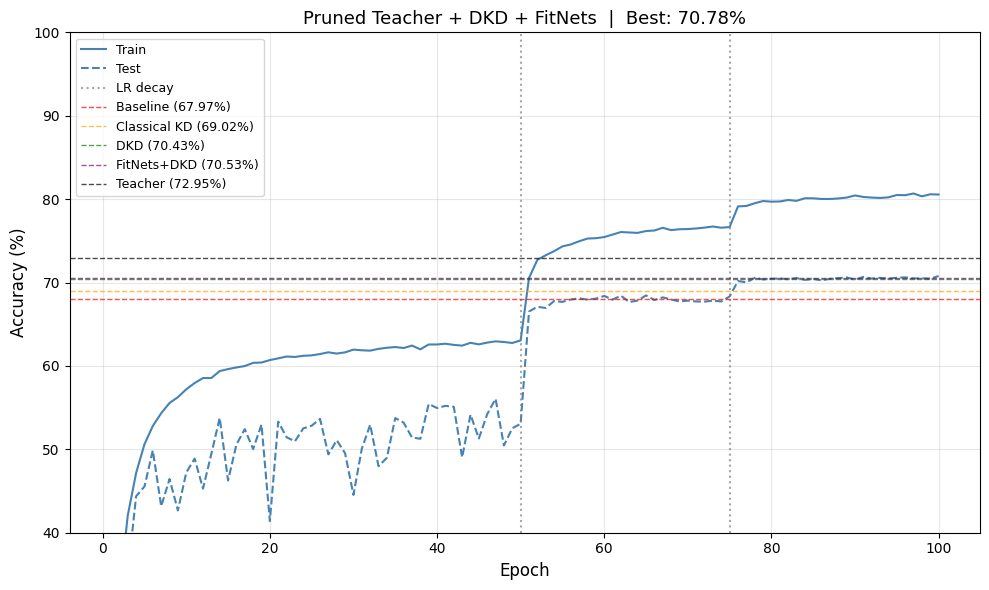

Plot saved to Drive.


In [11]:
TEACHER_ACC  = 72.95
BASELINE_ACC = 67.97
KD_ACC       = 69.02
DKD_ACC      = 70.43
FITNET_ACC   = 70.53

fig, ax = plt.subplots(figsize=(10, 6))
epochs_range = range(1, FULL_EPOCHS + 1)

ax.plot(epochs_range, train_accs, label='Train', color='steelblue', linewidth=1.5)
ax.plot(epochs_range, test_accs,  label='Test',  color='steelblue', linewidth=1.5, linestyle='--')
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.7, label='LR decay')
ax.axvline(x=75, color='gray', linestyle=':', alpha=0.7)
ax.axhline(y=BASELINE_ACC, color='red',    linestyle='--', linewidth=1, alpha=0.7, label=f'Baseline ({BASELINE_ACC:.2f}%)')
ax.axhline(y=KD_ACC,       color='orange', linestyle='--', linewidth=1, alpha=0.7, label=f'Classical KD ({KD_ACC:.2f}%)')
ax.axhline(y=DKD_ACC,      color='green',  linestyle='--', linewidth=1, alpha=0.7, label=f'DKD ({DKD_ACC:.2f}%)')
ax.axhline(y=FITNET_ACC,   color='purple', linestyle='--', linewidth=1, alpha=0.7, label=f'FitNets+DKD ({FITNET_ACC:.2f}%)')
ax.axhline(y=TEACHER_ACC,  color='black',  linestyle='--', linewidth=1, alpha=0.7, label=f'Teacher ({TEACHER_ACC:.2f}%)')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title(f'Pruned Teacher + DKD + FitNets  |  Best: {best_acc:.2f}%', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_ylim([40, 100])
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/pruned_dkd_fitnet_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to Drive.')

## 12. Final Results

In [12]:
best_student = ResNet20(num_classes=100).to(device)
best_student.load_state_dict(torch.load(CKPT_PATH, map_location=device))
final_acc = evaluate(best_student, test_loader, device)

print('=' * 60)
print('  Full Pipeline Comparison')
print('=' * 60)
print(f'  Teacher (ResNet-110)           : {TEACHER_ACC:.2f}%  — 1.74M params')
print(f'  Student baseline (no KD)       : {BASELINE_ACC:.2f}%  — 0.28M params')
print(f'  Classical KD (T=4)             : {KD_ACC:.2f}%  — 0.28M params')
print(f'  DKD                            : {DKD_ACC:.2f}%  — 0.28M params')
print(f'  FitNets + DKD                  : {FITNET_ACC:.2f}%  — 0.28M params')
print(f'  Pruned Teacher + DKD + FitNets : {final_acc:.2f}%  — 0.28M params')
print(f'  Remaining gap to teacher       : {TEACHER_ACC - final_acc:.2f}%')
print('=' * 60)
print(f'  Checkpoint: {CKPT_PATH}')

  Full Pipeline Comparison
  Teacher (ResNet-110)           : 72.95%  — 1.74M params
  Student baseline (no KD)       : 67.97%  — 0.28M params
  Classical KD (T=4)             : 69.02%  — 0.28M params
  DKD                            : 70.43%  — 0.28M params
  FitNets + DKD                  : 70.53%  — 0.28M params
  Pruned Teacher + DKD + FitNets : 70.78%  — 0.28M params
  Remaining gap to teacher       : 2.17%
  Checkpoint: /content/drive/MyDrive/kd_project/checkpoints/pruned_teacher_dkd_fitnet_student.pth
